# 실전 10-1: Research & Code Agents (실무 협업 AI 팀 구축)

## 1. 실험 목적
- **상황**: 팀장님이 "최근 애플(AAPL) 주가 관련된 최신 뉴스를 좀 찾아보고, 지난 1달치 주가 데이터를 다운로드해서 그래프로 예쁘게 그려서 보고해!" 라고 지시했습니다.
- **해결책**: 
  1. 웹 검색 능력을 가진 **[리서처 에이전트]**가 뉴스를 찾습니다.
  2. 파이썬 코드를 짤 수 있는 **[데이터 분석가 에이전트]**가 실시간 주식 데이터를 다운로드(yfinance)하여 차트를 그립니다.
  - 두 명의 AI가 하나의 워크플로우 안에서 협력하는 LangGraph Multi-Agent 기초 구조를 실습합니다.

In [13]:
import os
from dotenv import load_dotenv
from langchain_openai import ChatOpenAI

load_dotenv()

llm = ChatOpenAI(model="gpt-4o") # 코드 작성과 같은 복잡한 작업은 GPT-4o를 추천합니다.

## 2. 도구(Tools) 정의: 실제 세계와 상호작용하는 무기들

In [14]:
from langchain_community.tools import DuckDuckGoSearchRun
from langchain_experimental.tools import PythonREPLTool

# 1. 웹 검색 툴 (리서처 전용)
search_tool = DuckDuckGoSearchRun()

# 2. 파이썬 실행 툴 (분석가 전용)
python_repl_tool = PythonREPLTool()

# 확인: 두 가지 툴이 준비되었습니다.
print(search_tool.name, "-", search_tool.description)
print(python_repl_tool.name, "-", python_repl_tool.description)

duckduckgo_search - A wrapper around DuckDuckGo Search. Useful for when you need to answer questions about current events. Input should be a search query.
Python_REPL - A Python shell. Use this to execute python commands. Input should be a valid python command. If you want to see the output of a value, you should print it out with `print(...)`.


## 3. 최신 방식의 에이전트 생성
최신 `langchain`에서는 복잡한 프롬프트 템플릿과 AgentExecutor 없이, `create_agent` 함수 하나로 LangGraph 기반의 완벽한 에이전트를 직관적으로 생성할 수 있습니다.

In [15]:
from langchain.agents import create_agent

# 각자의 페르소나를 가진 에이전트 직원 2명 채용

# 직원 1: 리서처 (Researcher)
researcher_prompt = """
당신은 구글 수석 리서처입니다. 
사용자가 요청한 주제에 대해 웹 검색을 수행하고, 가장 핵심적인 정보를 요약해서 보고하세요.
"""
researcher_agent = create_agent(model=llm, tools=[search_tool], system_prompt=researcher_prompt)

# 직원 2: 데이터 분석가 (Data Analyst)
analyst_prompt = """
당신은 실리콘밸리 최고의 파이썬 데이터 분석가입니다.
yfinance 패키지를 사용하여 실시간 주식 데이터를 다운로드 받고, pandas로 분석하거나 matplotlib로 차트를 그립니다.
반드시 주어진 PythonREPLTool을 사용하여 코드를 실행하고 그 결과를 확인한 뒤 답변하세요.
코드를 작성할 때, 차트 이미지는 'apple_stock.png' 처럼 로컬 파일로 저장하도록 코드를 작성하세요. plt.show()는 환경에 따라 에러가 날 수 있습니다.
"""
analyst_agent = create_agent(model=llm, tools=[python_repl_tool], system_prompt=analyst_prompt)

## 4. 실전 투입: 각각 개별적으로 일 시켜보기 (단일 에이전트 모드)
먼저, 이들이 각자의 역할을 잘 수행하는지 단독으로 테스트해 봅니다. (새로운 create_agent는 CompiledStateGraph를 반환하므로, 최종 결과는 `res['messages'][-1].content`에 담깁니다.)

=== [1단계] 리서처에게 최근 애플 뉴스 검색 지시 ===

[리서처의 보고서]
 최근 1주일 내에 애플(AAPL) 주가에 영향을 미칠 만한 가장 큰 뉴스는 애플의 주식이 드물게 등급 강등을 받았다는 것입니다. 이로 인해 애플 주식은 하락세를 보이며 시장에 일부 영향을 미쳤습니다.


=== [2단계] 데이터 분석가에게 파이썬 코드 작성 및 차트 저장 지시 ===


Python REPL can execute arbitrary code. Use with caution.
[*********************100%***********************]  1 of 1 completed



[분석가의 보고서]
 애플(AAPL)의 최근 1달치 주가 데이터를 기반으로 종가(Close) 기준의 꺾은선 그래프를 'aapl_chart.png'로 저장하였습니다.


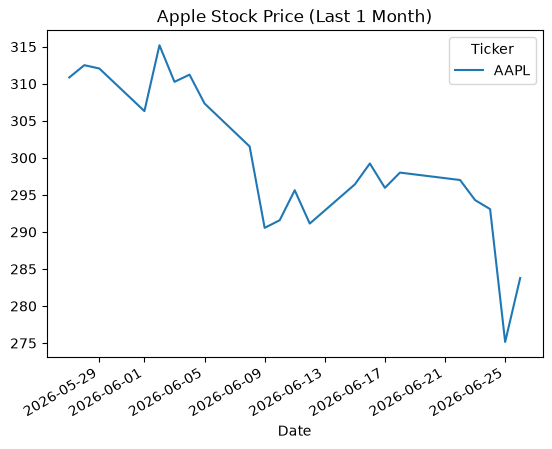

In [16]:
from langchain_core.messages import HumanMessage

print("=== [1단계] 리서처에게 최근 애플 뉴스 검색 지시 ===")
res1 = researcher_agent.invoke({
    "messages": [HumanMessage(content="애플(AAPL) 주가에 영향을 미칠 만한 최근 1주일 내의 가장 큰 뉴스는 뭐야?")]
})
print("\n[리서처의 보고서]\n", res1['messages'][-1].content)

print("\n" + "="*50 + "\n")

print("=== [2단계] 데이터 분석가에게 파이썬 코드 작성 및 차트 저장 지시 ===")
res2 = analyst_agent.invoke({
    "messages": [HumanMessage(content="파이썬으로 애플(AAPL)의 최근 1달치 주가 데이터를 다운받아서, 종가(Close) 기준으로 꺾은선 그래프를 그리고 'aapl_chart.png'로 저장해줘.")]
})
print("\n[분석가의 보고서]\n", res2['messages'][-1].content)

## 5. 확인하기
이 노트북이 있는 폴더(09_multi_agent 폴더의 상위 혹은 현재 작업 폴더)에 가시면 방금 AI가 스스로 코드를 짜서 만들어낸 `aapl_chart.png` 파일이 생성된 것을 볼 수 있습니다.

**[다음 노트북 예고]**
이 노트북에서는 우리가 수동으로 "리서처 너 일해!", "분석가 너 일해!" 라고 지시했습니다.
다음 노트북 `02_supervisor_workflow.ipynb`에서는 **[팀장(Supervisor)]** 노드를 만들어서, 팀장이 알아서 리서처와 분석가에게 일을 배분하고 최종 취합본을 내놓는 완벽한 Multi-Agent 그래프를 LangGraph로 그릴 것입니다.